In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline

# Загрузка данных
print("Загрузите steam_games.csv")
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
print(f"Датасет загружен: {df.shape[0]:,} строк, {df.shape[1]} столбцов")


Загрузите steam_games.csv


Saving steam_games_dataset.csv to steam_games_dataset (2).csv
Датасет загружен: 10,000 строк, 17 столбцов


In [2]:
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print(df.info())

# Поиск ключевых колонок и создание целевой переменной
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Создание целевой переменной "хит" (top-20% по владельцам или времени)
target_cols = [col for col in ['owners', 'average_forever', 'median_forever'] if col in df.columns]

if target_cols:
    # Преобразуем в числовой формат
    for col in target_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Берем максимум по всем метрикам популярности для определения хита
    df['popularity_score'] = df[target_cols].max(axis=1)
    threshold = df['popularity_score'].quantile(0.8)
    df['is_hit'] = (df['popularity_score'] >= threshold).astype(int)

    print(f"\nЦелевая переменная создана:")
    print(f"Хитов (класс 1): {df['is_hit'].sum():,} ({df['is_hit'].mean():.1%})")
    print(f"Не хитов (класс 0): {len(df) - df['is_hit'].sum():,} ({1-df['is_hit'].mean():.1%})")
else:
    print("Колонки для целевой переменной не найдены")


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            10000 non-null  int64  
 1   name             10000 non-null  object 
 2   developer        9967 non-null   object 
 3   publisher        9946 non-null   object 
 4   score_rank       5 non-null      float64
 5   positive         10000 non-null  int64  
 6   negative         10000 non-null  int64  
 7   userscore        10000 non-null  int64  
 8   owners           10000 non-null  object 
 9   average_forever  10000 non-null  int64  
 10  average_2weeks   10000 non-null  int64  
 11  median_forever   10000 non-null  int64  
 12  median_2weeks    10000 non-null  int64  
 13  price            10000 non-null  int64  
 14  initialprice     10000 non-null  int64  
 15  discount         10000 non-null  int64  
 16  ccu              10000 non-null  int6

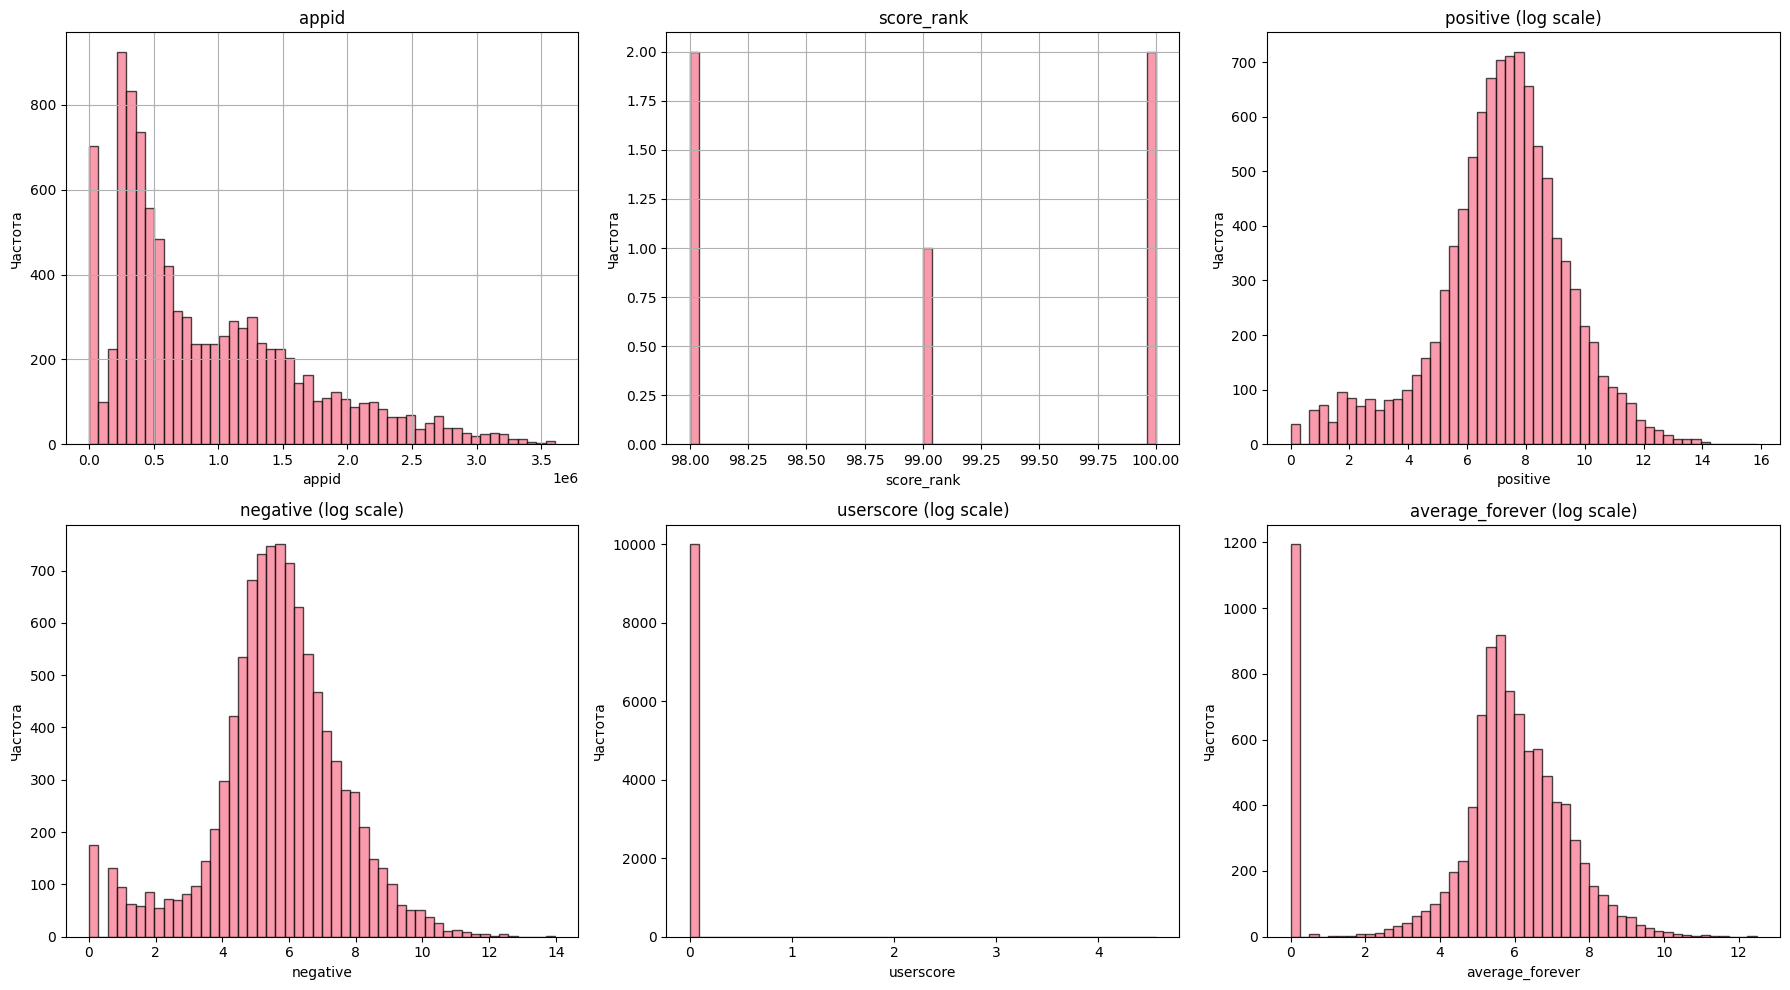

In [3]:
# Выбираем топ-6 числовых признаков для визуализации
plot_cols = numeric_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(plot_cols):
    if i < 6:
        ax = axes[i]
        data = df[col].dropna()
        if len(data) > 0:
            if data.max() > data.quantile(0.95) * 10:  # сильно скошено
                ax.hist(np.log1p(data), bins=50, alpha=0.7, edgecolor='black')
                ax.set_title(f'{col} (log scale)')
            else:
                data.hist(bins=50, ax=ax, alpha=0.7, edgecolor='black')
                ax.set_title(f'{col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Частота')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()


Сравнение хитов и не хитов
✗ owners: слишком мало данных (0)
✓ average_forever: 10000 валидных записей
✓ median_forever: 10000 валидных записей
✓ average_2weeks: 10000 валидных записей
✓ median_2weeks: 10000 валидных записей
✓ price: 10000 валидных записей
✓ initialprice: 10000 валидных записей
✓ discount: 10000 валидных записей
✓ positive: 10000 валидных записей
✓ negative: 10000 валидных записей
✓ userscore: 10000 валидных записей
✓ ccu: 10000 валидных записей

Будет проанализировано колонок: 11


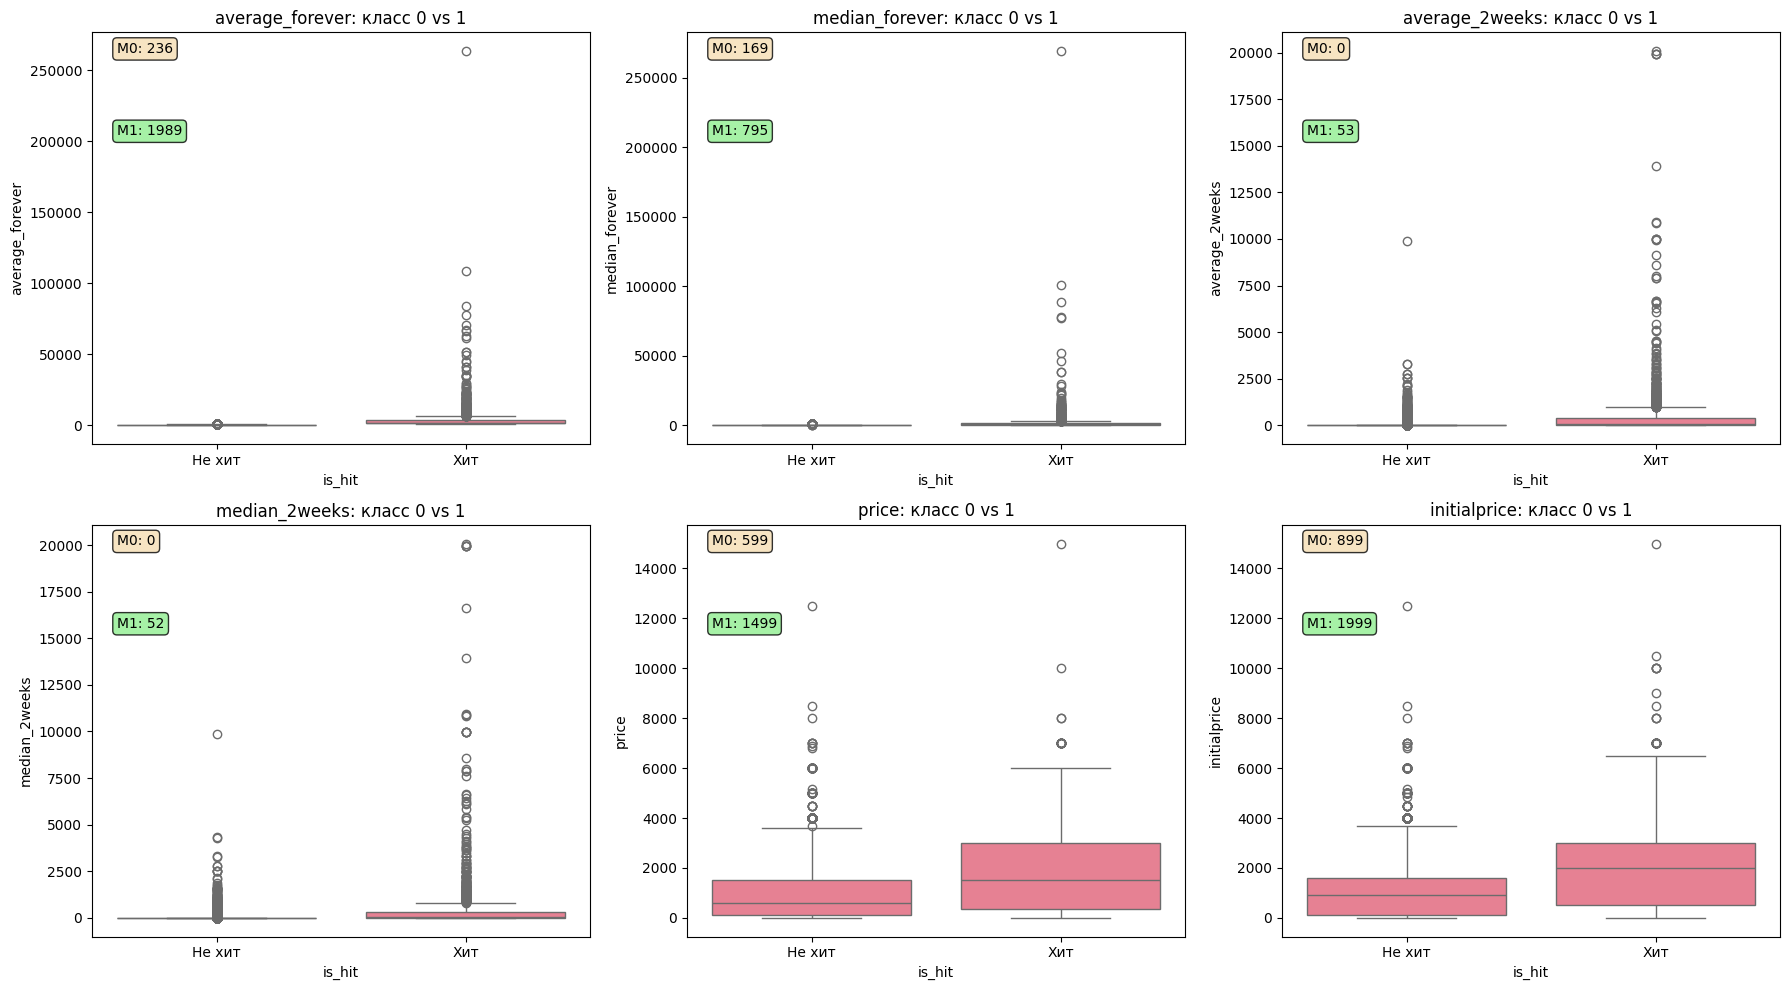


СРЕДНИЕ ЗНАЧЕНИЯ ПО КЛАССАМ:
       average_forever         median_forever        average_2weeks         \
                  mean  median           mean median           mean median   
is_hit                                                                       
0               300.10   236.0         202.76  169.0          35.91    0.0   
1              3912.65  1989.0        1761.63  795.0         418.25   53.0   

       median_2weeks           price          ... discount         positive  \
                mean median     mean  median  ...     mean median      mean   
is_hit                                        ...                             
0              40.02    0.0   939.49   599.0  ...      8.9    0.0   4407.91   
1             434.09   52.0  1897.22  1499.0  ...      7.8    0.0  43020.57   

               negative         userscore             ccu         
        median     mean  median      mean median     mean median  
is_hit                                           

In [13]:
print("Сравнение хитов и не хитов")

if 'is_hit' not in df.columns:
    print("Целевая переменная 'is_hit' отсутствует")
else:
    # Список потенциальных колонок для сравнения
    candidate_cols = [
        'owners', 'average_forever', 'median_forever', 'average_2weeks', 'median_2weeks',
        'price', 'initialprice', 'discount', 'positive', 'negative', 'userscore', 'ccu'
    ]

    # Фильтруем только существующие колонки с достаточным количеством данных
    valid_cols = []
    for col in candidate_cols:
        if col in df.columns:
            non_null_count = df[[col, 'is_hit']].dropna().shape[0]
            if non_null_count > 50:
                valid_cols.append(col)
                print(f"✓ {col}: {non_null_count} валидных записей")
            else:
                print(f"✗ {col}: слишком мало данных ({non_null_count})")

    print(f"\nБудет проанализировано колонок: {len(valid_cols)}")

    if valid_cols:
        # Строим графики только для валидных колонок
        n_cols = min(6, len(valid_cols))
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.ravel()

        for i, col in enumerate(valid_cols[:6]):
            ax = axes[i]
            data_subset = df[[col, 'is_hit']].dropna()

            if len(data_subset) > 0:
                sns.boxplot(data=data_subset, x='is_hit', y=col, ax=ax)
                ax.set_title(f'{col}: класс 0 vs 1')
                ax.set_xticklabels(['Не хит', 'Хит'])


                median_0 = data_subset[data_subset['is_hit'] == 0][col].median()
                median_1 = data_subset[data_subset['is_hit'] == 1][col].median()
                ax.text(0.05, 0.95, f'М0: {median_0:.0f}', transform=ax.transAxes,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
                ax.text(0.05, 0.75, f'М1: {median_1:.0f}', transform=ax.transAxes,
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
            else:
                ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{col}: пусто')

        for i in range(len(valid_cols), 6):
            fig.delaxes(axes[i])

        plt.tight_layout()
        plt.savefig('hits_comparison_fixed.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Табличное сравнение
        print("\nСРЕДНИЕ ЗНАЧЕНИЯ ПО КЛАССАМ:")
        stats = df[valid_cols + ['is_hit']].groupby('is_hit')[valid_cols].agg(['mean', 'median']).round(2)
        print(stats)
    else:
        print("Нет подходящих колонок для анализа")


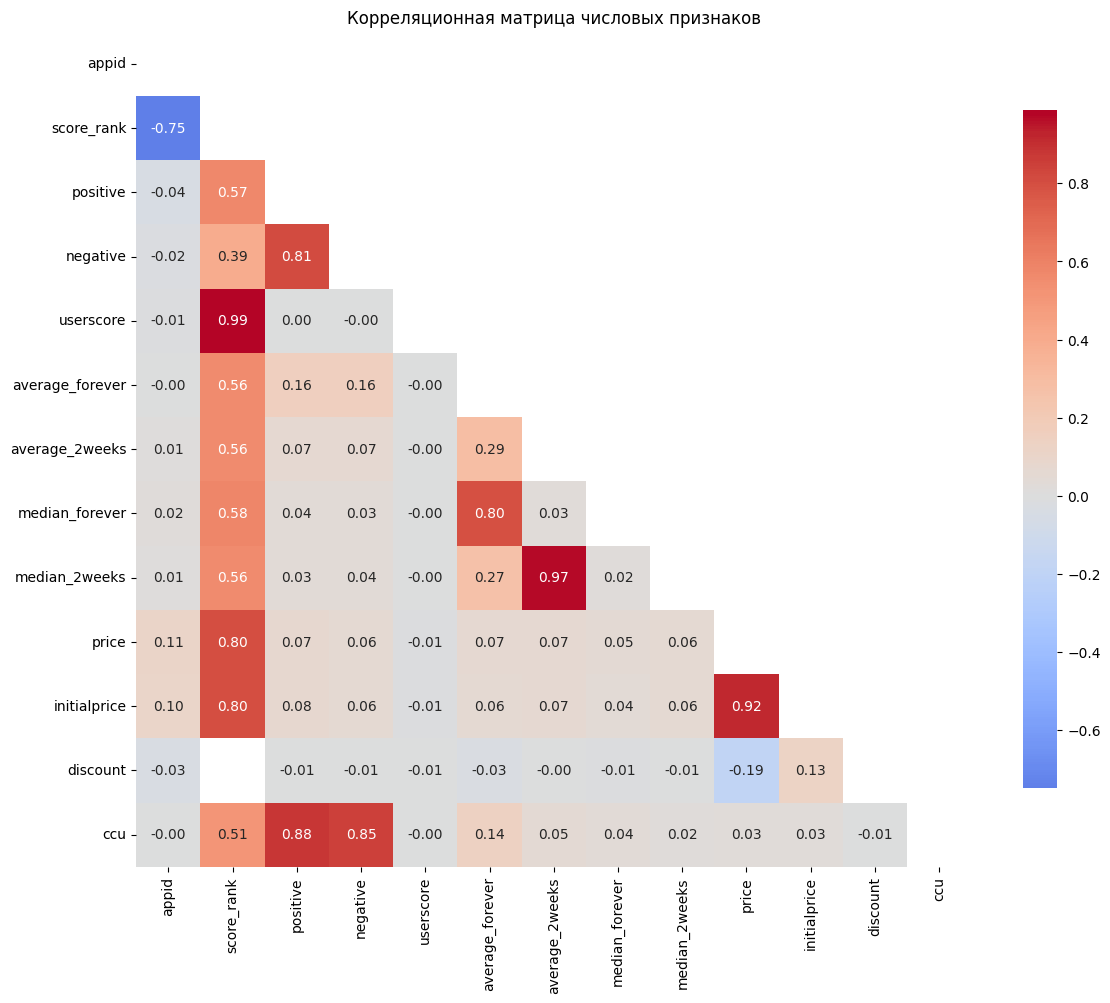

In [5]:
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
Найдено категориальных колонок: 3
Категории: ['name', 'developer', 'publisher']

Обрабатываем колонку: name
  Строк с данными: 10000
  → Недостаточно категорий с данными

Обрабатываем колонку: developer
  Строк с данными: 9967


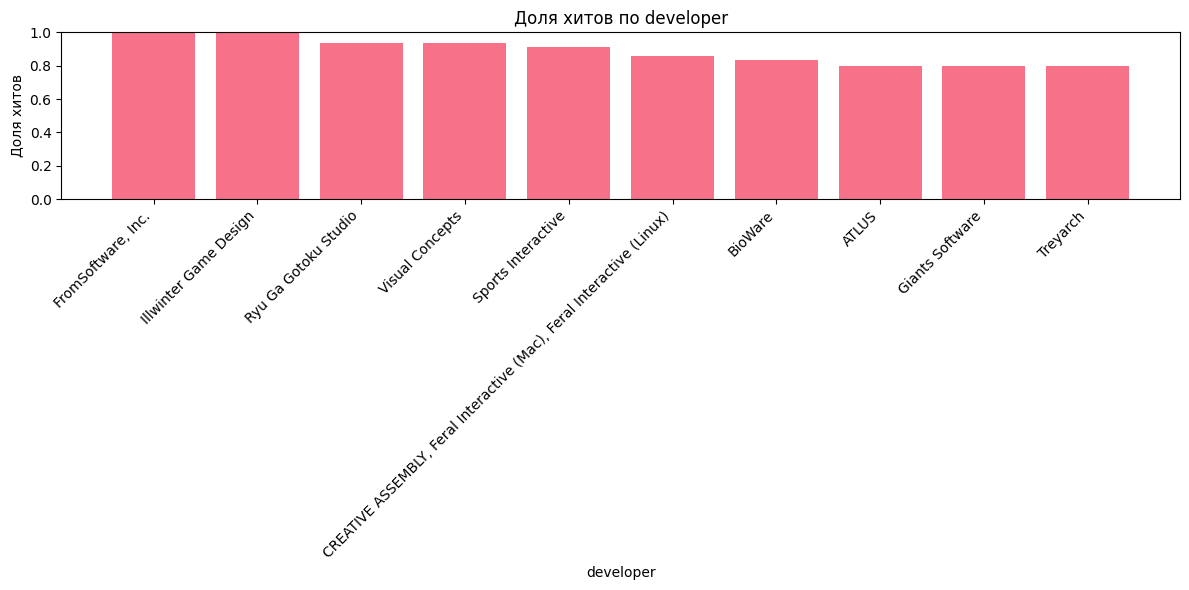

  → Построен график для 10 категорий
  Топ категория: FromSoftware, Inc. (100.0%)

Обрабатываем колонку: publisher
  Строк с данными: 9946


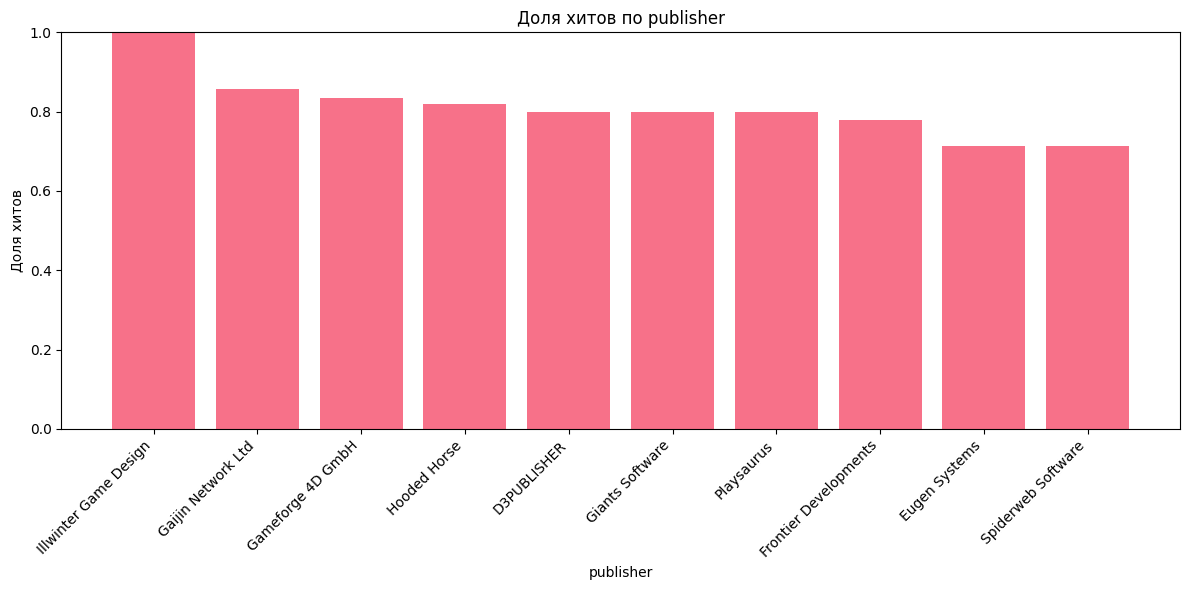

  → Построен график для 10 категорий
  Топ категория: Illwinter Game Design (100.0%)

Анализировано графиков: 2


In [11]:
print("АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Найдено категориальных колонок: {len(cat_cols)}")
print(f"Категории: {cat_cols}")

analyzed = 0
for col in cat_cols:
    print(f"\nОбрабатываем колонку: {col}")

    # Проверяем, есть ли в ней данные
    non_null_count = df[col].dropna().shape[0]
    print(f"  Строк с данными: {non_null_count}")

    if non_null_count < 10:
        print(f"  → Пропускаем: слишком мало данных")
        continue

    # Группируем по категориям и считаем долю хитов
    if 'is_hit' in df.columns:
        hit_rate = df.groupby(col)['is_hit'].agg(['mean', 'count']).reset_index()

        # Фильтруем категории с достаточным количеством примеров
        valid_categories = hit_rate[hit_rate['count'] >= 5]

        if len(valid_categories) >= 2:
            # Берем топ-10 категорий по доле хитов
            top_categories = valid_categories.nlargest(10, 'mean')

            plt.figure(figsize=(12, 6))
            plt.bar(range(len(top_categories)), top_categories['mean'])
            plt.title(f'Доля хитов по {col}')
            plt.ylabel('Доля хитов')
            plt.xlabel(col)
            plt.xticks(range(len(top_categories)), top_categories[col], rotation=45, ha='right')
            plt.ylim(0, 1)
            plt.tight_layout()
            plt.savefig(f'category_{col}_analysis.png', dpi=150, bbox_inches='tight')
            plt.show()

            print(f"  → Построен график для {len(top_categories)} категорий")
            print(f"  Топ категория: {top_categories.iloc[0][col]} ({top_categories.iloc[0]['mean']:.1%})")
            analyzed += 1
        else:
            print(f"   Недостаточно категорий с данными")
    else:
        print("  Нет целевой переменной 'is_hit'")

print(f"\nАнализировано графиков: {analyzed}")


In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропуски': missing,
    'Процент': missing_pct.round(2)
}).sort_values('Пропуски', ascending=False)

print("ПРОПУСКИ В ДАННЫХ:")
print(missing_df[missing_df['Пропуски'] > 0].head(10))

# Сохраняем сводку для отчета
eda_summary = {
    'Количество игр': df.shape[0],
    'Количество признаков': df.shape[1],
    'Числовых признаков': len(numeric_cols),
    'Категориальных признаков': len(cat_cols),
    'Количество хитов': int(df['is_hit'].sum()),
    'Доля хитов': f"{df['is_hit'].mean():.1%}",
    'Общее количество пропусков': int(missing.sum())
}

print("\nEDA SUMMARY :")
for key, value in eda_summary.items():
    print(f"{key}: {value}")


ПРОПУСКИ В ДАННЫХ:
            Пропуски  Процент
owners         10000   100.00
score_rank      9995    99.95
publisher         54     0.54
developer         33     0.33

EDA SUMMARY :
Количество игр: 10000
Количество признаков: 19
Числовых признаков: 13
Категориальных признаков: 3
Количество хитов: 2003
Доля хитов: 20.0%
Общее количество пропусков: 20082
